### Summarazation

In [84]:
!uv --version

uv 0.12.17 (635500036 2026-09-18 x86_64-pc-windows-msvc)


In [85]:
from dotenv import load_dotenv

load_dotenv()

True

In [86]:
# !uv add langchain_teddynote

#### Stuff

In [87]:
from langchain_community.document_loaders import TextLoader

loader = TextLoader("data/news.txt", encoding="utf-8")
docs = loader.load()

print(f"총 글자수: {len(docs[0].page_content)}")
print("\n====앞부분 미리보기====\n")
print(docs[0].page_content[:500])

총 글자수: 1708

====앞부분 미리보기====

제목: 
AI2, 상업 활용까지 자유로운 '진짜' 오픈 소스 LLM '올모' 출시

내용:
앨런AI연구소(AI2)가 완전한 오픈 소스 대형언어모델(LLM) '올모(OLMo)’를 출시했다. 데이터 수집, 학습, 배포의 전 과정을 투명하게 공개한 데다 상업적 사용까지 허용한 진정한 의미의 오픈 소스 LLM이라는 평가다.
벤처비트는 1일(현지시간) 비영리 민간 AI 연구기관인 AI2가 ‘최초의 진정한 오픈 소스 LLM 및 프레임워크’라고 소개한 ‘올모’를 출시했다고 보도했다. 
이에 따르면 올모는 모델 코드와 모델 가중치뿐만 아니라 훈련 코드, 훈련 데이터, 관련 툴킷 및 평가 툴킷도 제공한다. 이를 통해 모델이 어떻게 구축되었는지 심층적으로 분석, LLM의 작동 방식과 응답을 생성하는 원리를 더 잘 이해할 수 있다. 
올모 프레임워크는 70억 매개변수의 ‘올모 7B’ 등 4가지 변형 모델과 10억 매개변수의 ‘올모 1B’ 모델을 제공한다. 모델들은 훈련 데이터를 생성하는 코드를 포함해 


In [88]:
# !uv add langchain_classic

In [89]:
from langchain_core.prompts import PromptTemplate

prompt = PromptTemplate.from_template(
    """Please summarize the sentence according to the following REQUEST.
REQUEST:
1. Summarize the main points in bullet points in KOREAN.
2. Each summarized sentence must start with an emoji that fits the meaning of the each sentence.
3. Use various emojis to make the summary more interesting.
4. Translate the summary into KOREAN if it is written in ENGLISH.
5. DO NOT translate any technical terms.
6. DO NOT include any unnecessary information.

CONTEXT:
{context}

SUMMARY:
"""
)

In [90]:
from langchain_openai import ChatOpenAI
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_teddynote.callbacks import StreamingCallback

llm = ChatOpenAI(
    model="gpt-4o-mini",
    streaming=True,
    temperature=0,
    callbacks=[StreamingCallback()],
)

stuff_chain = create_stuff_documents_chain(llm, prompt)
answer = stuff_chain.invoke({"context": docs})

- 🚀 앨런AI연구소(AI2)가 완전한 오픈 소스 LLM '올모(OLMo)'를 출시했다.  
- 📊 데이터 수집, 학습, 배포 과정을 투명하게 공개하고 상업적 사용을 허용한다.  
- 🔍 올모는 모델 코드, 가중치, 훈련 코드, 데이터 및 평가 툴킷을 제공한다.  
- 🧩 70억 매개변수의 '올모 7B'와 10억 매개변수의 '올모 1B' 모델을 포함한 4가지 변형 모델이 있다.  
- 📈 훈련 데이터는 AI2의 '돌마(Dolma)' 데이터 세트를 기반으로 하며, 3조개의 토큰을 특징으로 한다.  
- 📝 아파치 2.0 라이선스에 따라 상업적 활용에 제한이 없다.  
- 💡 AI2의 올모 프로젝트 책임자는 투명성이 부족한 현재의 언어 모델에 대한 문제를 지적했다.  
- 🏆 올모는 상업용 제품과 동등한 성능을 보여주며, 일부 벤치마크 테스트에서 우수한 결과를 기록했다.  
- 🌍 비영어권 언어와 코드 생성 기능에 대한 제약이 있다.  
- 🔧 AI2는 올모를 지속적으로 개선할 계획이다.  
- 🌐 올모의 모든 리소스는 깃허브 및 허깅페이스에서 무료로 제공된다.  

#### Map-Reduce

In [91]:
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader("data/SPRI_AI_Brief_2023년12월호_F.pdf")
docs = loader.load()
docs = docs[3:8]
print(f"총 페이지수: {len(docs)}")

총 페이지수: 5


In [92]:
from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
)

map_prompt = PromptTemplate.from_template(
    """Summarize the following chunk and extract its key points. Focus only on the most important information and preserve the original meaning.

CONTEXT:
{context}

SUMMARY:
"""
)

map_prompt.pretty_print()

Summarize the following chunk and extract its key points. Focus only on the most important information and preserve the original meaning.

CONTEXT:
{context}

SUMMARY:



In [93]:
map_chain = map_prompt | llm | StrOutputParser()

In [94]:
doc_summaries = map_chain.batch(docs)

In [95]:
len(doc_summaries)

5

In [96]:
print(doc_summaries[0])

On October 30, 2023, President Biden signed an executive order aimed at ensuring the safe and trustworthy development and use of artificial intelligence (AI) in the U.S. The order outlines several key areas of focus:

1. **Safety and Security Standards**: Companies developing powerful AI systems must share safety test results and key information with the government, and standards for AI safety and reliability will be established.

2. **Equity and Civil Rights**: Measures will be expanded to prevent discrimination and bias in areas like law, housing, and healthcare due to irresponsible AI use, including best practices for AI in the criminal justice system.

3. **Consumer Protection and Worker Support**: The order promotes responsible AI use in healthcare and develops educational resources for AI in schools, while also addressing worker impacts from AI.

4. **Innovation and Competition**: The National Artificial Intelligence Research Resource (NAIRR) will enhance AI research across the U

In [97]:
reduce_prompt = PromptTemplate.from_template(
    """Combine the summaries from the Map step into one concise and coherent final summary. Remove redundant information and preserve the most important points.

DOC_SUMMARIES:
{doc_summaries}
"""
)

reduce_prompt.pretty_print()

Combine the summaries from the Map step into one concise and coherent final summary. Remove redundant information and preserve the most important points.

DOC_SUMMARIES:
{doc_summaries}



In [98]:
reduce_chain = reduce_prompt | llm | StrOutputParser()

In [99]:
from langchain_teddynote.messages import stream_response

answer = reduce_chain.stream(
    {"doc_summaries": "\n".join(doc_summaries), "language": "Korean"}
)
stream_response(answer)

On October 30, 2023, President Biden signed an executive order to ensure the safe and trustworthy development of artificial intelligence (AI) in the U.S., focusing on safety standards, equity, consumer protection, and innovation. Key measures include requiring companies to share safety test results, preventing discrimination in AI applications, promoting responsible AI use in healthcare, and enhancing AI research through the National Artificial Intelligence Research Resource (NAIRR).

In parallel, the G7 established an International Code of Conduct for Advanced AI Systems to promote voluntary adoption among companies. This initiative emphasizes risk assessment, transparency, collaboration, and the development of international standards to address social risks and protect data privacy.

At the AI Safety Summit in Bletchley Park, UK, on November 1-2, 2023, representatives from 28 countries signed the Bletchley Declaration, which stresses the need for collaborative efforts in AI safety. T

In [100]:
from langchain_core.runnables import chain

@chain
def map_reduce_chain(docs):
    map_llm = ChatOpenAI(
        model="gpt-4o-mini",
        temperature=0,
    )

    map_prompt = PromptTemplate.from_template(
      """Summarize the following chunk and extract its key points. Focus only on the most important information and preserve the original meaning.

    CONTEXT:
    {context}

    SUMMARY:
    """
    )

    map_chain = map_prompt | map_llm | StrOutputParser()

    reduce_prompt = PromptTemplate.from_template(
        """Combine the summaries from the Map step into one concise and coherent final summary. Remove redundant information and preserve the most important points.

        DOC_SUMMARIES:
        {doc_summaries}
        """
    )
    reduce_llm = ChatOpenAI(
        model="gpt-4o-mini",
        temperature=0,
        callbacks=[StreamingCallback()],
        streaming=True,
    )

    reduce_chain = reduce_prompt | reduce_llm | StrOutputParser()

    return reduce_chain.invoke(
        {"doc_summaries": "\n".join(doc_summaries), "language": "Korean"}
    )

In [101]:
answer = map_reduce_chain.invoke(docs)

On October 30, 2023, President Biden signed an executive order to ensure the safe and trustworthy development of artificial intelligence (AI) in the U.S., focusing on safety standards, equity, consumer protection, and innovation. Key measures include requiring companies to share safety test results, preventing discrimination in AI applications, promoting responsible AI use in healthcare, and enhancing AI research through the National Artificial Intelligence Research Resource (NAIRR).

In parallel, the G7 established an International Code of Conduct for Advanced AI Systems to promote voluntary adoption among companies. This initiative emphasizes risk assessment, transparency, collaboration, and the development of international standards to address social risks and protect data privacy.

At the AI Safety Summit in November 2023, representatives from 28 countries signed the Bletchley Declaration, which stresses the need for collaborative efforts in AI safety. The UK announced the creation

#### Map-Refine

In [102]:
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate

map_llm = ChatOpenAI(
    model="gpt-5-mini",
    temperature=0,
)

map_summary = PromptTemplate.from_template(
    """Summarize the following chunk and extract its key points. Focus on the most important information and preserve the original meaning.

DOCUMENTS:
{documents}

SUMMARY:"""
)

map_summary.pretty_print()

Summarize the following chunk and extract its key points. Focus on the most important information and preserve the original meaning.

DOCUMENTS:
{documents}

SUMMARY:


In [103]:
map_chain = map_summary | llm | StrOutputParser()

In [104]:
print(map_chain.invoke({"documents": docs[0], "language": "Korean"}))

On October 30, 2023, U.S. President Biden signed an executive order aimed at ensuring the safe and trustworthy development and use of artificial intelligence (AI). The order outlines several key areas of focus:

1. **Safety and Security Standards**: Companies developing powerful AI systems must share safety test results and key information with the U.S. government. Standards for verifying AI system safety and reliability, as well as guidelines for labeling AI-generated content, will be established.

2. **Equity and Civil Rights**: Measures will be expanded to prevent discrimination and bias in the use of AI in legal, housing, and healthcare sectors. This includes developing best practices for AI use in the criminal justice system and providing clear guidelines to prevent algorithmic discrimination in housing.

3. **Consumer Protection and Worker Support**: The order promotes responsible AI use in healthcare and the development of educational resources for AI tools in schools. It also a

In [105]:
input_doc = [{"documents": doc, "language": "Korean"} for doc in docs]

In [106]:
input_doc

[{'documents': Document(metadata={'producer': 'Hancom PDF 1.3.0.542', 'creator': 'Hwp 2018 10.0.0.13462', 'creationdate': '2023-12-08T13:28:38+09:00', 'author': 'dj', 'moddate': '2023-12-08T13:28:38+09:00', 'pdfversion': '1.4', 'source': 'data/SPRI_AI_Brief_2023년12월호_F.pdf', 'total_pages': 23, 'page': 3, 'page_label': '4'}, page_content='1. 정책/법제  2. 기업/산업 3. 기술/연구  4. 인력/교육\n미국, 안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령 발표 \nn 미국 바이든 대통령이 ‘안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령’에 서명하고 \n광범위한 행정 조치를 명시\nn 행정명령은 △AI의 안전과 보안 기준 마련 △개인정보보호 △형평성과 시민권 향상 △소비자 \n보호 △노동자 지원 △혁신과 경쟁 촉진 △국제협력을 골자로 함\nKEY Contents\n£ 바이든 대통령, AI 행정명령 통해 안전하고 신뢰할 수 있는 AI 개발과 활용 추진\nn 미국 바이든 대통령이 2023년 10월 30일 연방정부 차원에서 안전하고 신뢰할 수 있는 AI 개발과 \n사용을 보장하기 위한 행정명령을 발표\n∙ 행정명령은 △AI의 안전과 보안 기준 마련 △개인정보보호 △형평성과 시민권 향상 △소비자 보호 \n△노동자 지원 △혁신과 경쟁 촉진 △국제협력에 관한 내용을 포괄\nn (AI 안전과 보안 기준) 강력한 AI 시스템을 개발하는 기업에게 안전 테스트 결과와 시스템에 관한 \n주요 정보를 미국 정부와 공유할 것을 요구하고, AI 시스템의 안전성과 신뢰성 확인을 위한 표준 및 \nAI 생성 콘텐츠 표시를 위한 표준과 모범사례 확립을 추진\n∙ △1026 플롭스(FLOPS, Floa

In [107]:
print(map_chain.batch(input_doc))

['On October 30, 2023, U.S. President Biden signed an executive order aimed at ensuring the safe and trustworthy development and use of artificial intelligence (AI). The order outlines several key areas of focus:\n\n1. **Safety and Security Standards**: Companies developing powerful AI systems must share safety test results and key information with the U.S. government. Standards for verifying AI system safety and reliability, as well as guidelines for labeling AI-generated content, will be established.\n\n2. **Equity and Civil Rights**: Measures will be expanded to prevent discrimination and bias in the use of AI in legal, housing, and healthcare sectors. This includes developing best practices for AI use in the criminal justice system and providing clear guidelines to prevent algorithmic discrimination in housing.\n\n3. **Consumer Protection and Worker Support**: The order promotes responsible AI use in healthcare and the development of educational resources for AI tools in schools. I

In [108]:
from langchain_core.prompts import PromptTemplate

refine_prompt = PromptTemplate.from_template(
    """Improve the existing summary using the information from the new chunk. Combine important new information with the existing summary, remove redundancy, and keep the final summary concise and coherent.

PREVIOUS_SUMMARY:
{previous_summary}

CURRENT_SUMMARY:
{current_summary}"""
)

refine_prompt.pretty_print()

Improve the existing summary using the information from the new chunk. Combine important new information with the existing summary, remove redundancy, and keep the final summary concise and coherent.

PREVIOUS_SUMMARY:
{previous_summary}

CURRENT_SUMMARY:
{current_summary}


In [109]:
refine_llm = ChatOpenAI(
    model="gpt-5-mini",
    temperature=0,
)

refine_chain = refine_prompt | refine_llm | StrOutputParser()

In [110]:
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import chain

@chain
def map_refine_chain(docs):

    map_summary = PromptTemplate.from_template(
    """Summarize the following chunk and extract its key points. Focus on the most important information and preserve the original meaning.

    DOCUMENTS:
    {documents}

    SUMMARY:"""
    )

    map_chain = (
        map_summary
        | ChatOpenAI(
            model="gpt-5-mini",
            temperature=0,
        )
        | StrOutputParser()
    )

    input_doc = [{"documents": doc.page_content, "language": "Korean"} for doc in docs]

    doc_summaries = map_chain.batch(input_doc)

    refine_prompt = PromptTemplate.from_template(
    """Improve the existing summary using the information from the new chunk. Combine important new information with the existing summary, remove redundancy, and keep the final summary concise and coherent.

    PREVIOUS_SUMMARY:
    {previous_summary}

    CURRENT_SUMMARY:
    {current_summary}"""
    )

    refine_llm = ChatOpenAI(
        model="gpt-5-mini",
        temperature=0,
        callbacks=[StreamingCallback()],
        streaming=True,
    )

    refine_chain = refine_prompt | refine_llm | StrOutputParser()

    previous_summary = doc_summaries[0]

    for current_summary in doc_summaries[1:]:

        previous_summary = refine_chain.invoke(
            {
                "previous_summary": previous_summary,
                "current_summary": current_summary,
                "language": "Korean",
            }
        )
        print("\n\n-----\n\n")

    return previous_summary

In [111]:
refine_summary = map_refine_chain.invoke(docs)

KeyboardInterrupt: 

#### Chain of Density

In [ ]:
from langsmith import Client

client = Client()
cod_prompt = client.pull_prompt("teddynote/chain-of-density-prompt", dangerously_pull_public_prompt=True)

cod_prompt.pretty_print()

================================ System Message ================================

As an expert copy-writer, you will write increasingly concise, entity-dense summaries of the user provided {content_category}. The initial summary should be under {max_words} words and contain {entity_range} informative Descriptive Entities from the {content_category}.

A Descriptive Entity is:
- Relevant: to the main story.
- Specific: descriptive yet concise (5 words or fewer).
- Faithful: present in the {content_category}.
- Anywhere: located anywhere in the {content_category}.

# Your Summarization Process
- Read through the {content_category} and the all the below sections to get an understanding of the task.
- Pick {entity_range} informative Descriptive Entities from the {content_category} (";" delimited, do not add spaces).
- In your output JSON list of dictionaries, write an initial summary of max {max_words} words containing the Entities.
- You now have `[{"missing_entities": "...", "denser_summa

In [ ]:
import textwrap
from langsmith import Client
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import SimpleJsonOutputParser

cod_chain_inputs = {
    "content": lambda d: d.get("content"),
    "content_category": lambda d: d.get("content_category", "Article"),
    "entity_range": lambda d: d.get("entity_range", "1-3"),
    "max_words": lambda d: int(d.get("max_words", 80)),
    "iterations": lambda d: int(d.get("iterations", 5)),
}

cod_prompt = client.pull_prompt("teddynote/chain-of-density-prompt", dangerously_pull_public_prompt=True)

cod_chain = (
    cod_chain_inputs
    | cod_prompt
    |ChatOpenAI(model="gpt-4o-mini", temperature=0)
    | SimpleJsonOutputParser()
)

cod_final_summary_chain = cod_chain | (
    lambda output: output[-1].get(
        "denser_summary", '오류: 마지막 딕셔너리에 "denser_summary" 키가 없습니다'
    )
)

In [ ]:
content = docs[1].page_content
print(content)

SPRi AI Brief |  
2023-12월호
2
G7, 히로시마 AI 프로세스를 통해 AI 기업 대상 국제 행동강령에 합의
n G7이 첨단 AI 시스템을 개발하는 기업을 대상으로 AI 위험 식별과 완화를 위해 자발적인 
채택을 권고하는 AI 국제 행동강령을 마련
n 행동강령은 AI 수명주기 전반에 걸친 위험 평가와 완화, 투명성과 책임성의 보장, 정보공유와 
이해관계자 간 협력, 보안 통제, 콘텐츠 인증과 출처 확인 등의 조치를 요구
KEY Contents
£ G7, 첨단 AI 시스템의 위험 관리를 위한 국제 행동강령 마련
n 주요 7개국(G7)*은 2023년 10월 30일 ‘히로시마 AI 프로세스’를 통해 AI 기업 대상의 AI 국제 
행동강령(International Code of Conduct for Advanced AI Systems)에 합의
∙ G7은 2023년 5월 일본 히로시마에서 개최된 정상회의에서 생성 AI에 관한 국제규범 마련과 
정보공유를 위해 ‘히로시마 AI 프로세스’를 출범**
∙ 기업의 자발적 채택을 위해 마련된 이번 행동강령은 기반모델과 생성 AI를 포함한 첨단 AI 시스템의 
위험 식별과 완화에 필요한 조치를 포함
* 주요 7개국(G7)은 미국, 일본, 독일, 영국, 프랑스, 이탈리아, 캐나다를 의미
** 5월 정상회의에는 한국, 호주, 베트남 등을 포함한 8개국이 초청을 받았으나, AI 국제 행동강령에는 우선 G7 국가만 포함하여 채택
n G7은 행동강령을 통해 아래의 조치를 제시했으며, 빠르게 발전하는 기술에 대응할 수 있도록 
이해관계자 협의를 통해 필요에 따라 개정할 예정
∙ 첨단 AI 시스템의 개발 과정에서 AI 수명주기 전반에 걸쳐 위험을 평가 및 완화하는 조치를 채택하고, 
첨단 AI 시스템의 출시와 배포 이후 취약점과 오용 사고, 오용 유형을 파악해 완화
∙ 첨단 AI 시스템의 성능과 한계를 공개하고 적절하거나 부적절한 사용영역을 알리는 방법으로 투명성을 
보장하고 책임성을 강화
∙ 산업계, 정부, 시민사회, 학

In [ ]:
rsults: list[dict[str, str]] = []

for partial_json in cod_chain.stream(
    {"content": content, "content_category": "Article"}
):
    results = partial_json

    print(results, end="\r", flush=True)

total_summaries = len(results)
print("\n")

i = 1
for cod in results:
    added_entities = ", ".join(
        [
            ent.strip()
            for ent in cod.get(
                "missing_entities", 'ERR: "missing_entiies" key not found'
            ).split(";")
        ]
    )

    summary = cod.get("denser_summary", 'ERR: missing key "denser_summary"')

    print(
        f"### CoD Summary {i}/{total_summaries}, 추가된 엔티티: {added_entities}"
        + "\n"
    )

    print(textwrap.fill(summary, width=80) + "\n")
    i += 1

print("\n====[final summary]====\n")
print(summary)

[{'missing_entities': 'G7;AI 국제 행동강령;히로시마 AI 프로세스', 'denser_summary': 'G7은 2023년 10월 30일 히로시마 AI 프로세스를 통해 AI 기업을 위한 AI 국제 행동강령을 합의했다. 이 행동강령은 AI 위험 식별과 완화를 위한 조치를 포함하며, AI 수명주기 전반에 걸친 위험 평가, 투명성 보장, 정보공유 및 협력을 요구한다.'}, {'missing_entities': '위험 평가;투명성 보장;정보공유', 'denser_summary': 'G7은 2023년 10월 30일 히로시마 AI 프로세스를 통해 AI 기업을 위한 AI 국제 행동강령을 합의했다. 이 행동강령은 AI 위험 식별과 완화를 위한 위험 평가, 투명성 보장, 정보공유 및 협력을 요구하며, AI 수명주기 전반에 걸친 조치를 포함한다.'}, {'missing_entities': 'AI 수명주기;강력한 보안 통제;콘텐츠 인증', 'denser_summary': 'G7은 2023년 10월 30일 히로시마 AI 프로세스를 통해 AI 기업을 위한 AI 국제 행동강령을 합의했다. 이 행동강령은 AI 수명주기 전반에 걸친 위험 평가, 강력한 보안 통제, 콘텐츠 인증 및 투명성 보장, 정보공유와 협력을 요구한다.'}, {'missing_entities': 'AI 거버넌스;위험 완화;사회적 위험', 'denser_summary': 'G7은 2023년 10월 30일 히로시마 AI 프로세스를 통해 AI 기업을 위한 AI 국제 행동강령을 합의했다. 이 행동강령은 AI 수명주기 전반에 걸친 위험 평가, AI 거버넌스 및 위험 완화, 강력한 보안 통제, 사회적 위험 완화와 투명성 보장을 요구한다.'}, {'missing_entities': '기후 위기;세계 보건;교육', 'denser_summary': 'G7은 2023년 10월 30일 히로시마 AI 프로세스를 통해 AI 기업을 위한 AI 국제 행동강령을 합의했다. 이 행동강령은 AI 수명주기 전반에 걸친 위험 평가, 

#### Clustering-Map-Refine

In [ ]:
from langchain_community.document_loaders import PyMuPDFLoader

loader = PyMuPDFLoader("data\SPRI_AI_Brief_2023년12월호_F.pdf")
docs = loader.load()
len(docs)

<>:3: SyntaxWarning: invalid escape sequence '\S'
<>:3: SyntaxWarning: invalid escape sequence '\S'
C:\Users\user\AppData\Local\Temp\ipykernel_13148\4073569844.py:3: SyntaxWarning: invalid escape sequence '\S'
  loader = PyMuPDFLoader("data\SPRI_AI_Brief_2023년12월호_F.pdf")


23

In [ ]:
texts = "\n\n".join([doc.page_content for doc in docs])
len(texts)

27977

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)
split_docs = text_splitter.split_text(texts)

In [ ]:
len(split_docs)

79

In [ ]:
from langchain_openai import OpenAIEmbeddings
embeddings = OpenAIEmbeddings()

vectors = embeddings.embed_documents(split_docs)

In [ ]:
# !uv add scikit-learn

In [113]:
from sklearn.cluster import KMeans

num_clusters = 10

kmeans = KMeans(n_clusters=num_clusters, random_state=123).fit(vectors)

In [114]:
kmeans.labels_

array([3, 1, 1, 5, 0, 8, 8, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 3,
       7, 3, 7, 7, 7, 7, 4, 4, 4, 4, 9, 9, 9, 1, 2, 2, 2, 2, 5, 5, 5, 0,
       3, 0, 0, 5, 5, 5, 5, 0, 0, 0, 5, 0, 0, 0, 0, 3, 3, 3, 1, 1, 1, 1,
       5, 0, 0, 5, 6, 6, 6, 8, 0, 8, 8, 8, 3], dtype=int32)

In [ ]:
# !uv add matplotlib seaborn

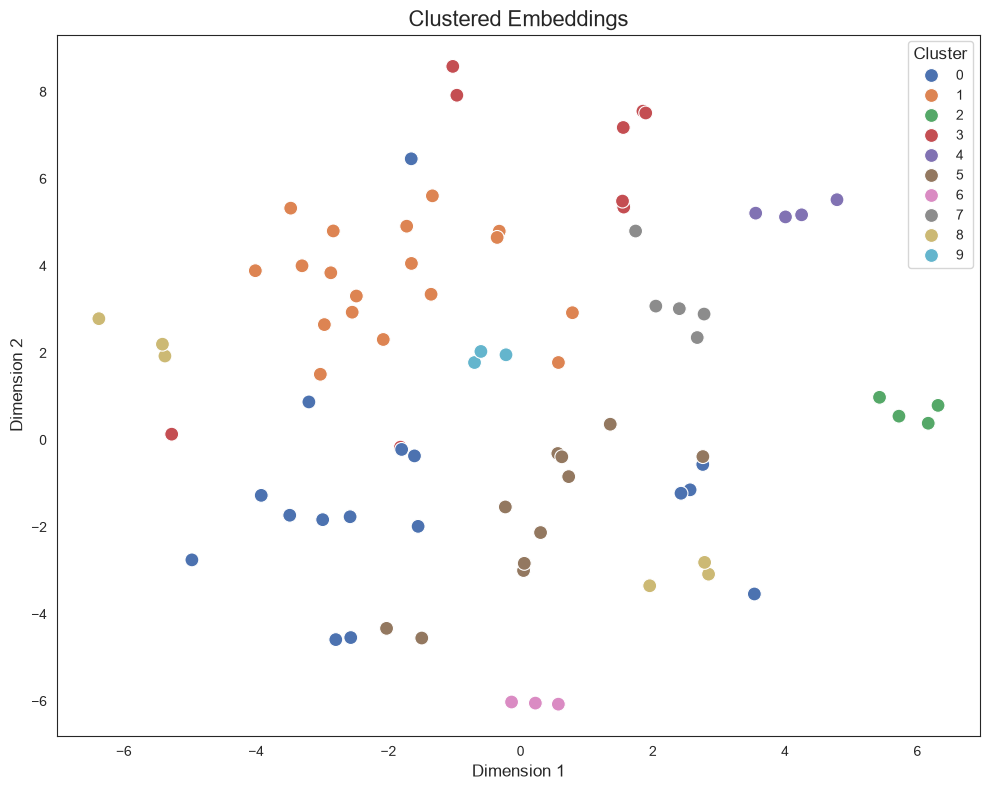

In [116]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import warnings

warnings.filterwarnings("ignore")

tsne = TSNE(n_components=2, random_state=42)
reduced_data_tsne = tsne.fit_transform(np.array(vectors))

sns.set_style("white")

plt.figure(figsize=(10,8))
sns.scatterplot(
    x=reduced_data_tsne[:, 0],
    y=reduced_data_tsne[:, 1],
    hue=kmeans.labels_,
    palette="deep",
    s=100,
)
plt.xlabel("Dimension 1", fontsize=12)
plt.ylabel("Dimension 2", fontsize=12)
plt.title("Clustered Embeddings", fontsize=16)
plt.legend(title="Cluster", title_fontsize=12)

plt.gcf().patch.set_facecolor("white")

plt.tight_layout()
plt.show()

In [117]:
import numpy as np

closest_indices = []

for i in range(num_clusters):
    distances = np.linalg.norm(vectors - kmeans.cluster_centers_[i], axis=1)

    closest_index = np.argmin(distances)

    closest_indices.append(closest_index)

In [118]:
closest_indices

[np.int64(55),
 np.int64(17),
 np.int64(37),
 np.int64(59),
 np.int64(29),
 np.int64(3),
 np.int64(70),
 np.int64(25),
 np.int64(5),
 np.int64(32)]

In [119]:
selected_indices = sorted(closest_indices)
selected_indices

[np.int64(3),
 np.int64(5),
 np.int64(17),
 np.int64(25),
 np.int64(29),
 np.int64(32),
 np.int64(37),
 np.int64(55),
 np.int64(59),
 np.int64(70)]

In [121]:
from langchain_core.documents import Document

selected_docs = [Document(page_content=split_docs[doc]) for doc in selected_indices]
selected_docs

[Document(metadata={}, page_content='▹ 알리바바 클라우드, 최신 LLM ‘통이치엔원 2.0’ 공개 ······················································ 9\n   ▹ 삼성전자, 자체 개발 생성 AI ‘삼성 가우스’ 공개 ··························································· 10\n   ▹ 구글, 앤스로픽에 20억 달러 투자로 생성 AI 협력 강화 ················································ 11\n   ▹ IDC, 2027년 AI 소프트웨어 매출 2,500억 달러 돌파 전망··········································· 12\n   ▹ 빌 게이츠, AI 에이전트로 인한 컴퓨터 사용의 패러다임 변화 전망································ 13'),
 Document(metadata={}, page_content='4. 인력/교육     \n   ▹ 영국 옥스퍼드 인터넷 연구소, AI 기술자의 임금이 평균 21% 높아······························· 18\n   \n   \n \nⅡ. 주요 행사\n   ▹CES 2024 ····························································································································· 19\n   ▹AIMLA 2024 ························································································································· 19'),
 Document(metadata={}, page_content='∙선언은 AI 안전 보장을 위해 국가, 국제기구, 기업,

In [125]:
refined_summary = map_refine_chain.invoke(selected_docs)

요약 및 핵심 포인트

1) 알리바바 클라우드 — 통이치엔원 2.0 공개 (p.9)  
- 요약: 알리바바 클라우드가 최신 대형언어모델(LLM) 통이치엔원 2.0을 발표.  
- 핵심: 자사 클라우드·AI 역량 강화, 기업·서비스용 AI 기능 고도화 기대.

2) 삼성전자 — 생성 AI 플랫폼 ‘삼성 가우스’ 공개 (p.10)  
- 요약: 삼성전자가 자체 개발한 생성형 AI 플랫폼·모델 ‘삼성 가우스’를 공개.  
- 핵심: 하드웨어·소프트웨어 결합으로 제품화·통합 추진, 글로벌 경쟁력 제고 의도.

3) 구글 — 앤스로픽(Anthropic)에 20억 달러 투자 (p.11)  
- 요약: 구글이 앤스로픽에 20억 달러를 투자하며 생성 AI 분야 협력을 강화.  
- 핵심: 전략적 자본투자를 통한 파트너십 확대 및 생태계 영향력 강화.

4) IDC 전망 — 2027년 AI 소프트웨어 매출 2,500억 달러 돌파 (p.12)  
- 요약: IDC는 2027년 전 세계 AI 소프트웨어 매출이 2,500억 달러를 넘을 것으로 전망.  
- 핵심: 상용화 가속에 따른 대규모 시장 성장 신호.

5) 빌 게이츠 전망 — AI 에이전트로 컴퓨터 사용 패러다임 변화 (p.13)  
- 요약: 빌 게이츠는 AI 에이전트의 등장으로 사용자 인터페이스와 업무 방식이 근본적으로 바뀔 것이라고 전망.  
- 핵심: 개인화·대화형 에이전트가 생산성 및 사용 경험 재정의.

6) 인력·교육 — AI 기술자 임금 프리미엄 (p.18)  
- 요약: 영국 옥스퍼드 인터넷연구소 조사 결과, AI(인공지능) 기술자의 평균 임금이 약 21% 더 높음.  
- 핵심: AI 전문인력 수요 증가에 따른 보상 격차·인재 확보 경쟁 심화 예상.

7) 주요 행사 (II) — CES 2024, AIMLA 2024 언급 (p.19)  
- 요약: CES 2024와 AIMLA 2024 등이 주요 행사로 소개됨.  
- 핵심: 기술·제품 발표와 네트워킹을 통한 산업 동향 반영 및 확산 기회.

종합적 의미:

In [126]:
print(refined_summary)

요약 및 핵심 포인트

전반적 맥락
- 빌 게이츠는 향후 약 5년 내 자연어 지시로 다양한 작업을 처리하는 AI 에이전트가 널리 보급돼 컴퓨터 사용 방식과 소프트웨어 산업을 근본적으로 바꾸고, 의료·교육·생산성·엔터테인먼트·쇼핑 등에서 고가 서비스의 대중화를 촉진할 것이라 전망함.
- 상용화 가속과 글로벌 경쟁 속에서 규제기관·국제사회는 첨단 AI의 안전성·투명성·책임성 확보를 위해 외부 안전 테스트·다자간 협력·법·정책 정비를 강화하고 있으며, 기업들은 안전성과 경쟁력 유지라는 이중 압박에 직면해 있음.

데이터 출처·투명성 문제 및 대응
- 문제: 학습·미세조정 데이터 출처가 불투명해 저작권·재라이선스 등 법적·윤리적 리스크가 큼.
- 조치: 연구진이 약 2,000개의 널리 쓰이는 미세조정 데이터셋을 감사해 원본 출처 태그·재라이선스 상태·작성자 등 메타데이터를 부여한 대화형 데이터 출처 탐색기를 공개, 누구나 라이선스 상태·구성·계보를 조회 가능하게 함.
- 주요 발견: GitHub·Papers with Code 등 크라우드소싱 출처에서 수집된 데이터는 라이선스 정보가 대체로 부실(누락 비율 72–83%)해 저작권·재라이선스 위험이 크며, 데이터 계보·라이선스 투명성 확보가 시급함.

LLM 환각(허위 생성) 평가 (신규)
- 평가: 머신러닝 데이터 관리기업 갈릴레오(Galileo)가 2023-11-15 발표한 ‘LLM 환각 지수(LLM Hallucination Index)’에서 주요 LLM의 허위·부정확 정보 생성 경향을 비교함(환각: AI가 부정확하거나 잘못된 정보를 생성하는 현상).
- 결과: GPT-4가 작업 유형과 무관하게 환각 발생이 가장 적었고, GPT-3.5 터보는 거의 동등한 성능을 보였음. 오픈소스 중에서는 메타의 Llama 2가 RAG(외부 지식 연동) 없이 수행하는 질의응답 및 장문 생성에서 최고 성능을 기록함.

산업 동향·안전 협력
- 주요 기업 동향: 알리바바 클라우드(통이치엔원 2.0), 삼성(생성 AI 플랫폼 ‘삼성 가우스’